In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (7,4),
    "font.size": 11,
    "axes.grid": True
})

In [18]:
import pandas as pd
from pathlib import Path

def load_latency_csv(path):
    """
    Carica un CSV e restituisce:
    - DataFrame con una sola colonna: lat_tep_ms
    """
    df = pd.read_csv(path)

    if "lat_rep_ms" not in df.columns:
        raise ValueError(f"'lat_tep_ms' column not found in {Path(path).name}")

    # forza tipo numerico
    df = df[["lat_rep_ms"]].copy()
    df["lat_rep_ms"] = pd.to_numeric(df["lat_rep_ms"], errors="coerce")

    # rimuove NaN eventuali
    df = df.dropna()

    return df

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

def extract_label(path):
    m = re.search(r"N(\d+)RATE([\d_\.]+)", path)
    if m:
        return f"N={m.group(1)}, R={m.group(2).replace('_','.')}"
    return Path(path).stem

In [25]:
queue_files = [
    "results_performance/queue_length_N10RATE5.csv",
    "results_performance/queue_length_N10RATE1.csv",
    "results_performance/queue_length_N10RATE0_2.csv",
    "results_performance/queue_length_N30RATE5.csv",
    "results_performance/queue_length_N30RATE1.csv",
    "results_performance/queue_length_N30RATE0_2.csv",
    "results_performance/queue_length_N50RATE5.csv",
    "results_performance/queue_length_N50RATE1.csv",
    "results_performance/queue_length_N50RATE0_2.csv",
    "results_performance/queue_length_N80RATE5.csv",
    "results_performance/queue_length_N80RATE1.csv",
    "results_performance/queue_length_N80RATE0_2.csv",
]

mqtt_files = [
    "results_performance/replication_latency_N10RATE5.csv",
    "results_performance/replication_latency_N10RATE1.csv",
    "results_performance/replication_latency_N10RATE0_2.csv",
    "results_performance/replication_latency_N30RATE5.csv",
    "results_performance/replication_latency_N30RATE1.csv",
    "results_performance/replication_latency_N30RATE0_2.csv",
    "results_performance/replication_latency_N50RATE5.csv",
    "results_performance/replication_latency_N50RATE1.csv",
    "results_performance/replication_latency_N50RATE0_2.csv",
    "results_performance/replication_latency_N80RATE5.csv",
    "results_performance/replication_latency_N80RATE1.csv",
    "results_performance/replication_latency_N80RATE0_2.csv",
]

In [26]:
def remove_outliers(df, ycol, max_value=1000.0):
    """
    Rimuove outlier hard-threshold.
    """
    before = len(df)
    df_filt = df[df[ycol] <= max_value].copy()
    after = len(df_filt)

    print(f"Filtered {before-after}/{before} samples > {max_value}")
    return df_filt

/tmp/ipykernel_1271040/575391616.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


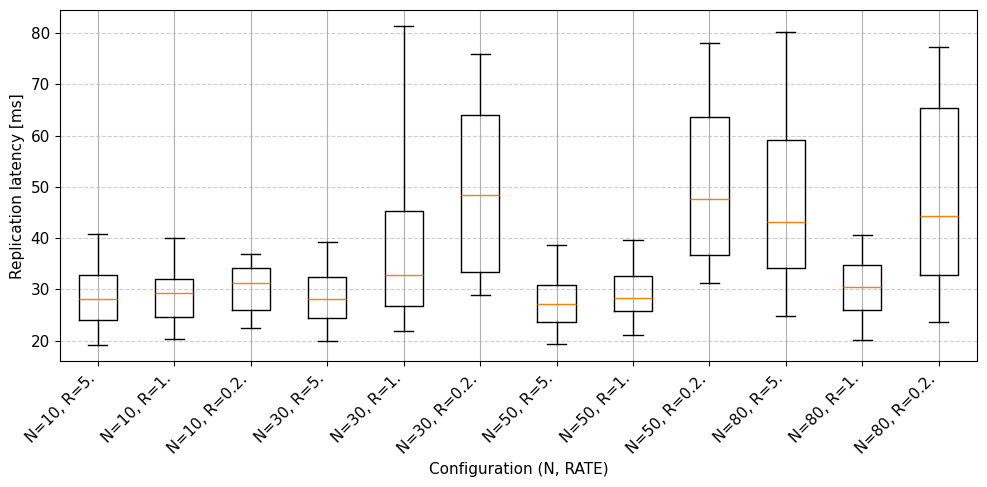

In [34]:
data = []
labels = []

for path in queue_files:
    df = pd.read_csv(path)
    lat = pd.to_numeric(df["lat_rep_ms"], errors="coerce")
    lat = lat[lat < 1000]      # outlier cut (come hai detto tu)

    data.append(lat.values)
    labels.append(extract_label(path))

plt.figure(figsize=(10, 5))
plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    whis=[5, 95]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Replication latency [ms]")
plt.xlabel("Configuration (N, RATE)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(
    "replication_latency_hist_RATE5.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()